# Configurable PoC: Blockchain-Enabled Adversarial Threat Intelligence Sharing

This notebook presents a configurable proof of concept for collaborative ransomware detection across multiple simulated PMCSO nodes.

The implementation keeps the blockchain-backed integrity flow and model weight / weight-delta sharing approach intact:

- Raw ransomware samples are not shared between nodes.
- The blockchain stores immutable hashes and metadata.
- Model weights or weight deltas are stored off-chain in this PoC store.
- Receiving nodes blend shared weight deltas using configurable trust values.

Run the configuration cell first, then execute the notebook top to bottom.

In [1]:
import os

# Reduce sources of nondeterminism in BLAS/threading before importing numerical libraries.
os.environ["PYTHONHASHSEED"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from dataclasses import dataclass, field
from pathlib import Path
import base64
import hashlib
import json
import pickle
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from web3 import Web3

sns.set_theme(style="whitegrid")

In [2]:
@dataclass
class ExperimentConfig:
    # Reproducibility and paths
    seed: int = 30
    dataset_path: str = "Ransomware_headers.csv"
    charts_dir: str = "charts"

    # Dataset split
    test_size: float = 0.20
    label_column: str = "GR"
    feature_start_column_index: int = 4

    # Model architecture and training
    hidden_layer_sizes: tuple = (16,)
    activation: str = "relu"
    baseline_max_iter: int = 200
    svm_kernel: str = "linear"

    # Numerical gradient approximation
    gradient_feature_sample: int = 512
    gradient_epsilon: float = 1e-4

    # Baseline adversarial attacks
    fgsm_eps: float = 2.0
    pgd_eps: float = 3.0
    pgd_step: float = 0.2
    pgd_iters: int = 40

    # Local robust model adversarial training
    robust_adv_epochs: int = 35
    robust_adv_eps: float = 2.5
    robust_batch_size: int = 50

    # PMCSO node simulation
    num_nodes: int = 4
    node_names: list = field(default_factory=lambda: ["A", "B", "C", "D"])
    clone_noise_std: float = 0.05
    node_samples_per_batch: int = 50
    node_warmup_samples: int = 100

    # Trust values for receiving nodes. Node A is the reporter in this PoC.
    # Add values for more nodes when num_nodes > 4, for example {"B": 0.7, "C": 0.5, "D": 0.8, "E": 0.6}.
    node_trust: dict = field(default_factory=lambda: {"B": 0.9, "C": 0.88, "D": 0.97})
    reporter_self_finetune_epochs: int = 17

    # Reported FGSM-like and PGD-like attacks against reporter node
    reporter_node: str = "A"
    force_evasion_if_needed: bool = True
    forced_fgsm_eps: float = 2.5  # Stronger fallback FGSM epsilon when CONFIG.fgsm_eps does not evade.

    # Held-out adversarial generalization set
    heldout_subset_size: int = 30
    heldout_eps_values: tuple = (0.5, 1.0, 1.5)
    heldout_iter_values: tuple = (5, 10)

    # Blockchain connection
    ganache_url: str = "http://127.0.0.1:8545"
    contract_abi_path: str = "ThreatIntelLedger_abi.json"
    contract_bytecode_path: str = "ThreatIntelLedger_bytecode.txt"
    deploy_gas: int = 3_000_000


CONFIG = ExperimentConfig()

# Auto-extend node names if CONFIG.num_nodes is increased and node_names is too short.
if len(CONFIG.node_names) < CONFIG.num_nodes:
    extra = list(string.ascii_uppercase[len(CONFIG.node_names):CONFIG.num_nodes])
    CONFIG.node_names = CONFIG.node_names + extra
CONFIG.node_names = CONFIG.node_names[:CONFIG.num_nodes]

Path(CONFIG.charts_dir).mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(CONFIG.seed)

CONFIG

ExperimentConfig(seed=30, dataset_path='Ransomware_headers.csv', charts_dir='charts', test_size=0.2, label_column='GR', feature_start_column_index=4, hidden_layer_sizes=(16,), activation='relu', baseline_max_iter=200, svm_kernel='linear', gradient_feature_sample=512, gradient_epsilon=0.0001, fgsm_eps=2.0, pgd_eps=3.0, pgd_step=0.2, pgd_iters=40, robust_adv_epochs=35, robust_adv_eps=2.5, robust_batch_size=50, num_nodes=4, node_names=['A', 'B', 'C', 'D'], clone_noise_std=0.05, node_samples_per_batch=50, node_warmup_samples=100, node_trust={'B': 0.9, 'C': 0.88, 'D': 0.97}, reporter_self_finetune_epochs=17, reporter_node='A', force_evasion_if_needed=True, forced_fgsm_eps=2.5, heldout_subset_size=30, heldout_eps_values=(0.5, 1.0, 1.5), heldout_iter_values=(5, 10), ganache_url='http://127.0.0.1:8545', contract_abi_path='ThreatIntelLedger_abi.json', contract_bytecode_path='ThreatIntelLedger_bytecode.txt', deploy_gas=3000000)

## 2. Model Weight Serialization and Weight-Delta Sharing Utilities

These functions implement the privacy-preserving weight handling used by the blockchain sharing flow. They serialize model weights, compute integrity hashes, calculate learned weight deltas, and blend received deltas into local models without sharing raw samples.

In [3]:
def serialize_model_weights(model):
    """Serialize MLPClassifier weights to base64 string.
    Model weights are abstract representations -- no individual sample data."""
    coefs = [c.tolist() for c in model.coefs_]
    intercepts = [i.tolist() for i in model.intercepts_]
    payload = {
        "coefs": coefs,
        "intercepts": intercepts,
        "architecture": list(model.hidden_layer_sizes),
        "activation": model.activation,
    }
    serialized = pickle.dumps(payload)
    return base64.b64encode(serialized).decode("utf-8")


def deserialize_model_weights(b64_string):
    """Deserialize base64 model weights back to dict."""
    return pickle.loads(base64.b64decode(b64_string))


def compute_weights_hash(model):
    """SHA256 hash of model weights for blockchain integrity verification."""
    weights_dict = {
        "coefs": [c.tolist() for c in model.coefs_],
        "intercepts": [i.tolist() for i in model.intercepts_],
    }
    blob = json.dumps(weights_dict, sort_keys=True).encode("utf-8")
    return hashlib.sha256(blob).hexdigest()


def extract_weights_arrays(model):
    """Extract model weights as numpy arrays (for local operations)."""
    return [np.array(c, dtype=np.float64) for c in model.coefs_], \
           [np.array(i, dtype=np.float64) for i in model.intercepts_]


def set_weights_arrays(model, coefs, intercepts):
    """Set model weights from numpy arrays."""
    model.coefs_ = coefs
    model.intercepts_ = intercepts
    return model


def compute_weight_delta(weights_before, model_after):
    """Compute the weight changes (deltas) from self-fine-tuning.
    
    weights_before can be either a model object or a deserialized weights dict.
    Returns (delta_payload, delta_hash).
    """
    # Extract "before" weights from either model or dict
    if isinstance(weights_before, dict):
        cb = [np.array(c, dtype=np.float64) for c in weights_before["coefs"]]
        ib = [np.array(i, dtype=np.float64) for i in weights_before["intercepts"]]
    else:
        cb, ib = extract_weights_arrays(weights_before)
    
    ca, ia = extract_weights_arrays(model_after)
    coefs_delta = [a - b for a, b in zip(ca, cb)]
    intercepts_delta = [a - b for a, b in zip(ia, ib)]
    
    payload = {
        "coefs_delta": [c.tolist() for c in coefs_delta],
        "intercepts_delta": [i.tolist() for i in intercepts_delta],
        "architecture": list(model_after.hidden_layer_sizes),
        "activation": model_after.activation,
    }
    return payload, "0x" + hashlib.sha256(
        json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()


def apply_weight_delta_to_model(model, delta_dict, blend_alpha=0.5):
    """Blend shared weight deltas with local weights (federated averaging).
    
    Instead of replacing local weights, this blends the received weight
    deltas: new_weights = local_weights + alpha * delta.
    
    blend_alpha controls trust in shared intelligence (0=ignore, 1=full trust).
    """
    coefs_local, intercepts_local = extract_weights_arrays(model)
    coefs_delta = [np.array(c, dtype=np.float64) for c in delta_dict["coefs_delta"]]
    intercepts_delta = [np.array(i, dtype=np.float64) for i in delta_dict["intercepts_delta"]]
    
    coefs_new = [cl + blend_alpha * cd for cl, cd in zip(coefs_local, coefs_delta)]
    intercepts_new = [il + blend_alpha * id_ for il, id_ in zip(intercepts_local, intercepts_delta)]
    return set_weights_arrays(model, coefs_new, intercepts_new)


def verify_weights_hash(model, expected_hash):
    """Verify that model weights match the expected blockchain hash."""
    return compute_weights_hash(model) == expected_hash

## 3. Load and Preprocess Dataset

In [4]:
print("=" * 60)
print("Loading & Preprocessing Ransomware Dataset")
print("=" * 60)

data = pd.read_csv(CONFIG.dataset_path)
print(f"Dataset loaded. Shape: {data.shape}")

X = data.iloc[:, CONFIG.feature_start_column_index:]
y = data[CONFIG.label_column]
print(f"Features: {X.shape}, Labels: {y.shape}")
print(f"Label distribution: {pd.Series(y).value_counts().to_dict()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
min_val, max_val = X_scaled.min(), X_scaled.max()
print(f"Scaled range: [{min_val:.4f}, {max_val:.4f}]")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y.values,
    test_size=CONFIG.test_size,
    random_state=CONFIG.seed,
    stratify=y,
)
y_train, y_test = y_train.astype(np.int64), y_test.astype(np.int64)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

X_test_ransomware = X_test[y_test == 1]
y_test_ransomware = y_test[y_test == 1]
print(f"Ransomware test samples: {X_test_ransomware.shape[0]}")

Loading & Preprocessing Ransomware Dataset
Dataset loaded. Shape: (2157, 1028)
Features: (2157, 1024), Labels: (2157,)
Label distribution: {0: 1134, 1: 1023}
Scaled range: [-30.2642, 46.4327]
Train: (1725, 1024), Test: (432, 1024)
Ransomware test samples: 205


## 4. Evaluation and Attack Helpers

In [5]:
def evaluate_model(model, X_true, y_true, model_name="Model", verbose=True):
    y_pred = model.predict(X_true)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_true)[:, 1]
    else:
        y_pred_proba = y_pred
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    unique = set(y_true)
    auc = roc_auc_score(y_true, y_pred_proba) if len(unique) > 1 else None
    if verbose:
        print(f"--- {model_name} ---")
        print(f"  Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}", end="")
        if auc is not None:
            print(f"  AUC: {auc:.4f}")
        else:
            print("  AUC: N/A")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}


def compute_numerical_gradient(model, x_input, target_class=1, epsilon=None, n_samples=None):
    """Approximate gradient using a random subset of features (speed optimization)."""
    if epsilon is None:
        epsilon = CONFIG.gradient_epsilon
    if n_samples is None:
        n_samples = CONFIG.gradient_feature_sample
    grad = np.zeros_like(x_input, dtype=np.float32)
    orig_proba = model.predict_proba(x_input.reshape(1, -1))[0, target_class]
    feat_indices = RNG.choice(len(x_input), size=min(n_samples, len(x_input)), replace=False)
    for i in feat_indices:
        x_plus = np.copy(x_input); x_plus[i] += epsilon
        p_plus = model.predict_proba(x_plus.reshape(1, -1))[0, target_class]
        x_minus = np.copy(x_input); x_minus[i] -= epsilon
        p_minus = model.predict_proba(x_minus.reshape(1, -1))[0, target_class]
        grad[i] = (p_plus - p_minus) / (2 * epsilon)
    return grad


def generate_pgd_batch(model, X_list, eps, iters, step=None):
    if step is None:
        step = eps / iters
    advs = []
    for i in range(len(X_list)):
        orig = X_list[i]
        current = np.copy(orig)
        for _ in range(iters):
            g = compute_numerical_gradient(model, current)
            current = current - step * np.sign(g)
            p = np.clip(current - orig, -eps, eps)
            current = orig + p
            current = np.clip(current, min_val, max_val)
            if model.predict(current.reshape(1, -1))[0] == 0:
                break
        advs.append(current)
    return np.array(advs)

## 5. Train Baseline Models

In [6]:
print("=" * 60)
print("Training Baseline Models")
print("=" * 60)

baseline_dnn = MLPClassifier(
    hidden_layer_sizes=CONFIG.hidden_layer_sizes,
    activation=CONFIG.activation,
    solver="adam",
    max_iter=CONFIG.baseline_max_iter,
    random_state=CONFIG.seed,
    verbose=False,
)
print("Training Baseline DNN (MLPClassifier)...")
baseline_dnn.fit(X_train, y_train)
dnn_metrics = evaluate_model(baseline_dnn, X_test, y_test, "Baseline DNN")
print("Baseline DNN training complete.\n")

baseline_svm = SVC(kernel=CONFIG.svm_kernel, random_state=CONFIG.seed, probability=True)
print("Training Baseline SVM...")
baseline_svm.fit(X_train, y_train)
svm_metrics = evaluate_model(baseline_svm, X_test, y_test, "Baseline SVM")

Training Baseline Models
Training Baseline DNN (MLPClassifier)...
--- Baseline DNN ---
  Acc: 0.9653  Prec: 0.9612  Rec: 0.9659  F1: 0.9635  AUC: 0.9923
Baseline DNN training complete.

Training Baseline SVM...
--- Baseline SVM ---
  Acc: 0.9560  Prec: 0.9604  Rec: 0.9463  F1: 0.9533  AUC: 0.9860


## 6. Generate FGSM and PGD Adversarial Samples

In [7]:
print("=" * 60)
print("Generating Adversarial Attacks")
print("=" * 60)

adv_samples_fgsm = []
successful_fgsm = 0
for i in range(len(X_test_ransomware)):
    orig = X_test_ransomware[i]
    grad = compute_numerical_gradient(baseline_dnn, orig)
    adv = orig - CONFIG.fgsm_eps * np.sign(grad)
    adv = np.clip(adv, min_val, max_val)
    if baseline_dnn.predict(adv.reshape(1, -1))[0] == 0 and y_test_ransomware[i] == 1:
        successful_fgsm += 1
    adv_samples_fgsm.append(adv)
x_test_adv_fgsm = np.array(adv_samples_fgsm)
adv_acc_fgsm = accuracy_score(y_test_ransomware, baseline_dnn.predict(x_test_adv_fgsm))
print(f"FGSM (eps={CONFIG.fgsm_eps}): {successful_fgsm}/{len(X_test_ransomware)} evasions, Acc={adv_acc_fgsm:.4f}")

adv_samples_pgd = []
successful_pgd = 0
for i in range(len(X_test_ransomware)):
    orig = X_test_ransomware[i]
    current = np.copy(orig)
    for _ in range(CONFIG.pgd_iters):
        grad = compute_numerical_gradient(baseline_dnn, current)
        current = current - CONFIG.pgd_step * np.sign(grad)
        perturb = np.clip(current - orig, -CONFIG.pgd_eps, CONFIG.pgd_eps)
        current = orig + perturb
        current = np.clip(current, min_val, max_val)
        if baseline_dnn.predict(current.reshape(1, -1))[0] == 0:
            break
    if baseline_dnn.predict(current.reshape(1, -1))[0] == 0 and y_test_ransomware[i] == 1:
        successful_pgd += 1
    adv_samples_pgd.append(current)
x_test_adv_pgd = np.array(adv_samples_pgd)
adv_acc_pgd = accuracy_score(y_test_ransomware, baseline_dnn.predict(x_test_adv_pgd))
print(f"PGD (eps={CONFIG.pgd_eps}, iters={CONFIG.pgd_iters}): {successful_pgd}/{len(X_test_ransomware)} evasions, Acc={adv_acc_pgd:.4f}")

Generating Adversarial Attacks
FGSM (eps=2.0): 80/205 evasions, Acc=0.6098
PGD (eps=3.0, iters=40): 87/205 evasions, Acc=0.5756


## 7. Local Adversarial Training

In [8]:
print("=" * 60)
print("Local Adversarial Training (Robust DNN)")
print("=" * 60)

robust_dnn = MLPClassifier(
    hidden_layer_sizes=CONFIG.hidden_layer_sizes,
    activation=CONFIG.activation,
    solver="adam",
    max_iter=CONFIG.baseline_max_iter,
    random_state=CONFIG.seed,
    verbose=False,
)

for epoch in range(CONFIG.robust_adv_epochs):
    print(f"  Adversarial training epoch {epoch + 1}/{CONFIG.robust_adv_epochs}...", end=" ", flush=True)
    rw_indices = np.where(y_train == 1)[0]
    sel = RNG.choice(rw_indices, min(CONFIG.robust_batch_size, len(rw_indices)), replace=False)
    X_rw = X_train[sel]
    y_rw = y_train[sel]
    adv_train = []
    for j in range(len(X_rw)):
        orig = X_rw[j]
        g = compute_numerical_gradient(baseline_dnn, orig)
        a = np.clip(orig - CONFIG.robust_adv_eps * np.sign(g), min_val, max_val)
        adv_train.append(a)
    adv_train_np = np.array(adv_train)
    X_comb = np.vstack((X_train, adv_train_np))
    y_comb = np.hstack((y_train, y_rw))
    robust_dnn.partial_fit(X_comb, y_comb, classes=np.array([0, 1]))
    print("done", flush=True)
robust_dnn.max_iter = 1

robust_fgsm_acc = accuracy_score(y_test_ransomware, robust_dnn.predict(x_test_adv_fgsm))
robust_pgd_acc = accuracy_score(y_test_ransomware, robust_dnn.predict(x_test_adv_pgd))
print(f"Robust DNN on FGSM: {robust_fgsm_acc:.4f}  |  on PGD: {robust_pgd_acc:.4f}")

Local Adversarial Training (Robust DNN)
  Adversarial training epoch 1/35... done
  Adversarial training epoch 2/35... done
  Adversarial training epoch 3/35... done
  Adversarial training epoch 4/35... done
  Adversarial training epoch 5/35... done
  Adversarial training epoch 6/35... done
  Adversarial training epoch 7/35... done
  Adversarial training epoch 8/35... done
  Adversarial training epoch 9/35... done
  Adversarial training epoch 10/35... done
  Adversarial training epoch 11/35... done
  Adversarial training epoch 12/35... done
  Adversarial training epoch 13/35... done
  Adversarial training epoch 14/35... done
  Adversarial training epoch 15/35... done
  Adversarial training epoch 16/35... done
  Adversarial training epoch 17/35... done
  Adversarial training epoch 18/35... done
  Adversarial training epoch 19/35... done
  Adversarial training epoch 20/35... done
  Adversarial training epoch 21/35... done
  Adversarial training epoch 22/35... done
  Adversarial training 

## 8. Baseline and Robustness Charts

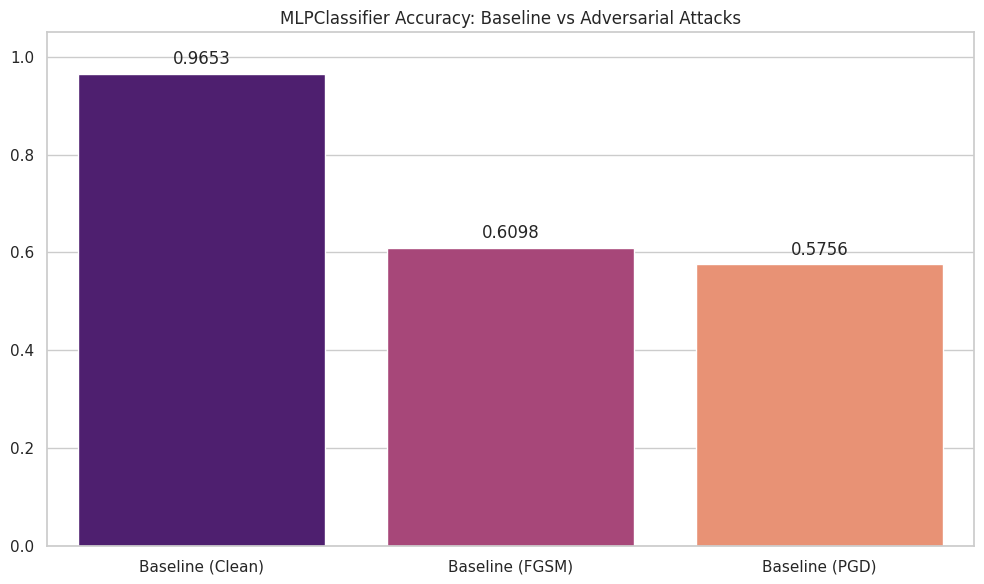

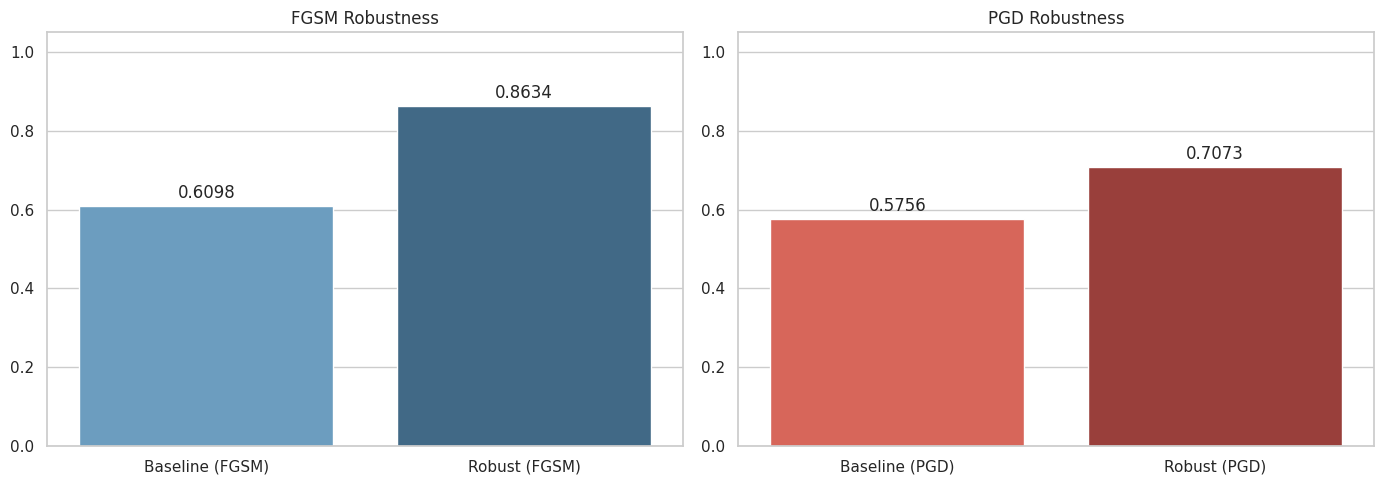

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
labels1 = ["Baseline (Clean)", "Baseline (FGSM)", "Baseline (PGD)"]
accs1 = [dnn_metrics["accuracy"], adv_acc_fgsm, adv_acc_pgd]
sns.barplot(x=labels1, y=accs1, hue=labels1, palette="magma", legend=False, ax=ax)
for i, v in enumerate(accs1):
    ax.text(i, v + 0.02, f"{v:.4f}", ha="center", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("MLPClassifier Accuracy: Baseline vs Adversarial Attacks")
fig.tight_layout()
fig.savefig(Path(CONFIG.charts_dir) / "baseline_vs_adversarial_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
labels_f = ["Baseline (FGSM)", "Robust (FGSM)"]
accs_f = [adv_acc_fgsm, robust_fgsm_acc]
sns.barplot(x=labels_f, y=accs_f, hue=labels_f, palette="Blues_d", legend=False, ax=ax1)
for i, v in enumerate(accs_f):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha="center")
ax1.set_ylim(0, 1.05)
ax1.set_title("FGSM Robustness")

labels_p = ["Baseline (PGD)", "Robust (PGD)"]
accs_p = [adv_acc_pgd, robust_pgd_acc]
sns.barplot(x=labels_p, y=accs_p, hue=labels_p, palette="Reds_d", legend=False, ax=ax2)
for i, v in enumerate(accs_p):
    ax2.text(i, v + 0.02, f"{v:.4f}", ha="center")
ax2.set_ylim(0, 1.05)
ax2.set_title("PGD Robustness")
fig2.tight_layout()
fig2.savefig(Path(CONFIG.charts_dir) / "robustness_improvement.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Blockchain Connection and Contract Deployment

Start Ganache before running this cell. The notebook deploys a fresh `ThreatIntelLedger` contract for the presentation run.

In [10]:
print("=" * 60)
print("Connecting to Ganache Blockchain & Deploying Smart Contract")
print("=" * 60)

w3 = Web3(Web3.HTTPProvider(CONFIG.ganache_url))
if not w3.is_connected():
    raise ConnectionError(f"Failed to connect to Ganache at {CONFIG.ganache_url}. Start Ganache first.")
print(f"Connected. Chain ID: {w3.eth.chain_id}, Block: {w3.eth.block_number}")

accounts = w3.eth.accounts
if len(accounts) < CONFIG.num_nodes:
    raise ValueError(f"Ganache exposes {len(accounts)} accounts, but CONFIG.num_nodes={CONFIG.num_nodes}.")

PMCSO_ACCOUNTS = {name: accounts[i] for i, name in enumerate(CONFIG.node_names)}
print("PMCSO Accounts:")
for name, acct in PMCSO_ACCOUNTS.items():
    bal = w3.from_wei(w3.eth.get_balance(acct), "ether")
    print(f"  PMCSO {name}: {acct} ({bal:.2f} ETH)")

w3.eth.default_account = accounts[0]

with open(CONFIG.contract_abi_path) as f:
    contract_abi = json.load(f)
with open(CONFIG.contract_bytecode_path) as f:
    contract_bytecode = f.read().strip()

ThreatIntelLedger_Contract = w3.eth.contract(abi=contract_abi, bytecode=contract_bytecode)

tx = ThreatIntelLedger_Contract.constructor().build_transaction({
    "from": w3.eth.default_account,
    "gas": CONFIG.deploy_gas,
    "gasPrice": w3.eth.gas_price,
})
tx_hash = w3.eth.send_transaction(tx)
tx_receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
contract_address = tx_receipt.contractAddress
deployed_contract = w3.eth.contract(address=contract_address, abi=contract_abi)
print(f"Contract deployed at: {contract_address}")

Connecting to Ganache Blockchain & Deploying Smart Contract
Connected. Chain ID: 1337, Block: 40
PMCSO Accounts:
  PMCSO A: 0xaa21b93d6FB37174556552d9380CD0F51ef595cB (999.97 ETH)
  PMCSO B: 0xCcB4C1e9F5487Dd892330F1ae4E0DEc91b4817a8 (1000.00 ETH)
  PMCSO C: 0x89969b4677028b19cAd9969ad314E40531EBaaC6 (1000.00 ETH)
  PMCSO D: 0xe879167491e2F07771DE4a6d012243e517DEf403 (1000.00 ETH)
Contract deployed at: 0x3A28857dc832a3a7Ab5beC5f19716D30d4065154


## 10. Blockchain Submission Helper

The helper stores only a hash and metadata on-chain. The off-chain dictionary simulates secure P2P/IPFS transfer for the PoC.

In [11]:
OFFCHAIN_WEIGHT_STORE = {}


def submit_model_weights_to_chain(contract, model, reporter_account, attack_desc):
    """Submit MODEL WEIGHT HASH to blockchain + store weights off-chain.
    
    HIPAA/GDPR compliant approach:
    - Blockchain stores hash only (immutable integrity proof, cheap)
    - Actual model weights stored off-chain (IPFS/secure channel simulation)
    - Model weights are abstract -- no individual sample data is ever shared
    """
    weights_b64 = serialize_model_weights(model)
    weights_hash = compute_weights_hash(model)
    
    # Store weights off-chain (simulates IPFS / secure P2P transfer)
    OFFCHAIN_WEIGHT_STORE[weights_hash] = weights_b64
    
    # On-chain: only hash + metadata summary (gas-efficient, immutable audit trail)
    details = json.dumps({
        "attack_description": attack_desc,
        "weights_hash_sha256": weights_hash,
        "architecture": list(model.hidden_layer_sizes),
        "activation": model.activation,
        "storage": "offchain",
        "sharing_policy": "HIPAA_GDPR_compliant__no_sample_data_shared",
    })
    
    ioc_hash_bytes = w3.to_bytes(hexstr="0x" + weights_hash)
    
    tx_hash = contract.functions.submitIntel(
        ioc_hash_bytes, details
    ).transact({"from": reporter_account})
    receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
    print(f"  Model weight hash submitted. Hash: {weights_hash[:16]}... Tx: {tx_hash.hex()[:16]}... Status: {receipt.status}")
    return weights_hash, receipt.status

## 11. Clone Base Model into Configurable PMCSO Nodes

Each PMCSO starts from the same baseline model with a small Gaussian perturbation. They have not seen the reported attack before PMCSO A discovers it.

In [12]:
print("=" * 60)
print(f"Cloning Baseline Model into PMCSO Nodes ({', '.join(CONFIG.node_names)})")
print("=" * 60)

pmcso_models = {}


def make_node_model(seed_offset=0):
    return MLPClassifier(
        hidden_layer_sizes=CONFIG.hidden_layer_sizes,
        activation=CONFIG.activation,
        solver="adam",
        max_iter=1,
        random_state=CONFIG.seed + seed_offset,
        verbose=False,
        warm_start=True,
    )


def clone_base_model_with_noise(base_model, node_name, seed_offset=0):
    """Clone the baseline model into a PMCSO node and add small Gaussian weight noise."""
    print(f"\nCloning baseline model for PMCSO {node_name}...")
    model = make_node_model(seed_offset)
    model.fit(X_train[:CONFIG.node_warmup_samples], y_train[:CONFIG.node_warmup_samples])
    local_rng = np.random.default_rng(CONFIG.seed + seed_offset)

    base_coefs, base_intercepts = extract_weights_arrays(base_model)
    noisy_coefs = [c + local_rng.normal(0, CONFIG.clone_noise_std, size=c.shape) for c in base_coefs]
    noisy_intercepts = [i + local_rng.normal(0, CONFIG.clone_noise_std, size=i.shape) for i in base_intercepts]
    set_weights_arrays(model, noisy_coefs, noisy_intercepts)
    model.max_iter = 1

    pmcso_models[node_name] = model
    acc = evaluate_model(model, X_test, y_test, f"PMCSO {node_name} clone (clean)", verbose=False)
    print(f"  PMCSO {node_name} cloned. Clean test acc: {acc['accuracy']:.4f}")
    return model


for i, name in enumerate(CONFIG.node_names):
    clone_base_model_with_noise(baseline_dnn, name, seed_offset=i * 100)

Cloning Baseline Model into PMCSO Nodes (A, B, C, D)

Cloning baseline model for PMCSO A...
  PMCSO A cloned. Clean test acc: 0.9514

Cloning baseline model for PMCSO B...
  PMCSO B cloned. Clean test acc: 0.9398

Cloning baseline model for PMCSO C...
  PMCSO C cloned. Clean test acc: 0.9491

Cloning baseline model for PMCSO D...
  PMCSO D cloned. Clean test acc: 0.9491


/home/vivek/Projects/ai-projects/Blockchain-enabled-Adversarial-Threat-Intelligence-Sharing-for-Robust-Ransomware-Detection-air-gaps/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/vivek/Projects/ai-projects/Blockchain-enabled-Adversarial-Threat-Intelligence-Sharing-for-Robust-Ransomware-Detection-air-gaps/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/vivek/Projects/ai-projects/Blockchain-enabled-Adversarial-Threat-Intelligence-Sharing-for-Robust-Ransomware-Detection-air-gaps/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) rea

## 12. Reporter Node Reports FGSM/PGD Evasions and Shares a Weight Delta

Node `CONFIG.reporter_node` finds successful FGSM-like and PGD-like evasions, self-fine-tunes against the combined reported batch, computes the learned weight delta, stores that delta off-chain, and records the delta hash on-chain.

PMCSO A: FGSM/PGD Evasions -> Share MODEL WEIGHT DELTA on Blockchain
PMCSO A reported 200 FGSM-like evasions (eps=2.0)
PMCSO A reported 197 PGD-like evasions (eps=3.0, step=0.2, iters=40)
PMCSO A will train on 397 total reported evasions
First reported evasion index: 0; prediction: 0 (True: 1)

--- PMCSO A: Self Fine-Tuning Against Reported FGSM/PGD Evasion Batch ---
  PMCSO A (post fine-tune) first reported prediction: 0 (was 0 before, True: 1)
  PMCSO A detection on combined reported batch: before=0.0000, after=0.5819


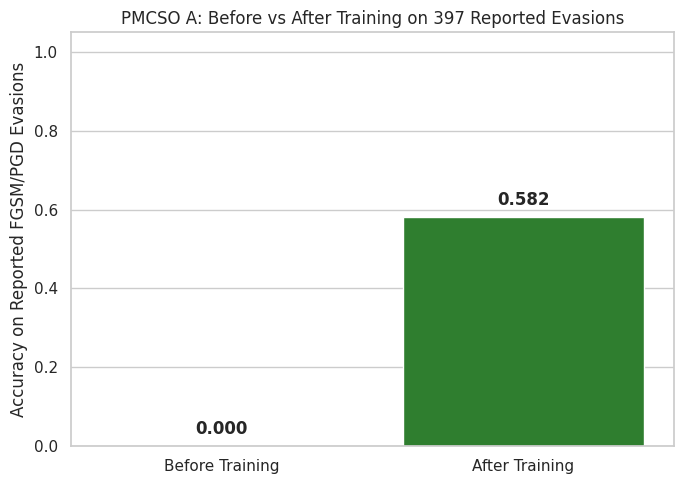


--- Sharing WEIGHT DELTA on Blockchain ---
(Weight deltas encode learned resilience, no sample data is shared.)
  Weight delta submitted. Hash: 0xf3c460a11642eb... Tx: 88bc9dbddb8d... Status: 1


In [13]:
print("=" * 60)
print(f"PMCSO {CONFIG.reporter_node}: FGSM/PGD Evasions -> Share MODEL WEIGHT DELTA on Blockchain")
print("=" * 60)

reporter = CONFIG.reporter_node
if reporter not in pmcso_models:
    raise ValueError(f"Reporter node {reporter!r} is not in CONFIG.node_names.")

reporter_model = pmcso_models[reporter]

def collect_reporter_fgsm_evasions(model, eps):
    """Collect every ransomware test sample that an FGSM-like attack makes benign."""
    reports = []
    for idx in range(len(X_test_ransomware)):
        orig = X_test_ransomware[idx]
        true_label = y_test_ransomware[idx]
        grad = compute_numerical_gradient(model, orig)
        adv = orig - eps * np.sign(grad)
        adv = np.clip(adv, min_val, max_val)
        pred = model.predict(adv.reshape(1, -1))[0]
        if true_label == 1 and pred == 0:
            reports.append({
                "index": idx,
                "original": orig,
                "adversarial": adv,
                "true_label": true_label,
                "prediction": pred,
                "eps": eps,
            })
    return reports


def collect_reporter_pgd_evasions(model, eps, step, iters):
    """Collect every ransomware test sample that a PGD-like attack makes benign."""
    reports = []
    for idx in range(len(X_test_ransomware)):
        orig = X_test_ransomware[idx]
        true_label = y_test_ransomware[idx]
        current = np.copy(orig)
        for _ in range(iters):
            grad = compute_numerical_gradient(model, current)
            current = current - step * np.sign(grad)
            perturb = np.clip(current - orig, -eps, eps)
            current = orig + perturb
            current = np.clip(current, min_val, max_val)
            if model.predict(current.reshape(1, -1))[0] == 0:
                break
        pred = model.predict(current.reshape(1, -1))[0]
        if true_label == 1 and pred == 0:
            reports.append({
                "index": idx,
                "original": orig,
                "adversarial": current,
                "true_label": true_label,
                "prediction": pred,
                "eps": eps,
                "step": step,
                "iters": iters,
            })
    return reports

fgsm_reports = collect_reporter_fgsm_evasions(reporter_model, CONFIG.fgsm_eps)
reported_fgsm_eps = CONFIG.fgsm_eps
if not fgsm_reports and CONFIG.force_evasion_if_needed:
    print(f"No reporter FGSM evasion found at eps={CONFIG.fgsm_eps}. Trying eps={CONFIG.forced_fgsm_eps}...")
    fgsm_reports = collect_reporter_fgsm_evasions(reporter_model, CONFIG.forced_fgsm_eps)
    reported_fgsm_eps = CONFIG.forced_fgsm_eps

pgd_reports = collect_reporter_pgd_evasions(reporter_model, CONFIG.pgd_eps, CONFIG.pgd_step, CONFIG.pgd_iters)

if not fgsm_reports and not pgd_reports:
    raise RuntimeError("No FGSM-like or PGD-like reporter evasion was found. Increase attack eps values for the demo.")

reported_evasion_reports = []
for report in fgsm_reports:
    report = dict(report)
    report["attack_type"] = "FGSM"
    reported_evasion_reports.append(report)
for report in pgd_reports:
    report = dict(report)
    report["attack_type"] = "PGD"
    reported_evasion_reports.append(report)

reported_adv_samples = np.array([report["adversarial"] for report in reported_evasion_reports])
true_labels_reported = np.array([report["true_label"] for report in reported_evasion_reports])
reported_attack_indices = [report["index"] for report in reported_evasion_reports]
reported_adv_sample = reported_adv_samples[0]
true_label_reported = true_labels_reported[0]
reporter_pred = reported_evasion_reports[0]["prediction"]
reported_attack_index = reported_attack_indices[0]
reporter_weights_pre = {
    "coefs": [c.tolist() for c in reporter_model.coefs_],
    "intercepts": [i.tolist() for i in reporter_model.intercepts_],
}
print(f"PMCSO {reporter} reported {len(fgsm_reports)} FGSM-like evasions (eps={reported_fgsm_eps})")
print(f"PMCSO {reporter} reported {len(pgd_reports)} PGD-like evasions (eps={CONFIG.pgd_eps}, step={CONFIG.pgd_step}, iters={CONFIG.pgd_iters})")
print(f"PMCSO {reporter} will train on {len(reported_evasion_reports)} total reported evasions")
print(f"First reported evasion index: {reported_attack_index}; prediction: {reporter_pred} (True: {true_label_reported})")

print(f"\n--- PMCSO {reporter}: Self Fine-Tuning Against Reported FGSM/PGD Evasion Batch ---")
X_self_ft = np.vstack((X_train[:CONFIG.node_samples_per_batch], reported_adv_samples))
y_self_ft = np.hstack((y_train[:CONFIG.node_samples_per_batch], true_labels_reported))
for _ in range(CONFIG.reporter_self_finetune_epochs):
    pmcso_models[reporter].partial_fit(X_self_ft, y_self_ft, classes=np.array([0, 1]))
pmcso_models[reporter].max_iter = 1
reporter_post_ft_pred = pmcso_models[reporter].predict(reported_adv_sample.reshape(1, -1))[0]
reporter_post_batch_preds = pmcso_models[reporter].predict(reported_adv_samples)
reporter_batch_acc_before = 0.0
reporter_batch_acc_after = accuracy_score(true_labels_reported, reporter_post_batch_preds)
print(f"  PMCSO {reporter} (post fine-tune) first reported prediction: {reporter_post_ft_pred} (was {reporter_pred} before, True: {true_label_reported})")
print(f"  PMCSO {reporter} detection on combined reported batch: before={reporter_batch_acc_before:.4f}, after={reporter_batch_acc_after:.4f}")

reporter_training_impact = {
    "Before Training": reporter_batch_acc_before,
    "After Training": reporter_batch_acc_after,
}
fig_reporter, ax_reporter = plt.subplots(figsize=(7, 5))
labels_reporter = list(reporter_training_impact.keys())
vals_reporter = list(reporter_training_impact.values())
sns.barplot(x=labels_reporter, y=vals_reporter, hue=labels_reporter, palette=["salmon", "forestgreen"], legend=False, ax=ax_reporter)
for i, v in enumerate(vals_reporter):
    ax_reporter.text(i, v + 0.03, f"{v:.3f}", ha="center", fontweight="bold")
ax_reporter.set_ylim(0, 1.05)
ax_reporter.set_ylabel("Accuracy on Reported FGSM/PGD Evasions")
ax_reporter.set_title(f"PMCSO {reporter}: Before vs After Training on {len(reported_evasion_reports)} Reported Evasions")
fig_reporter.tight_layout()
fig_reporter.savefig(Path(CONFIG.charts_dir) / "reporter_training_impact.png", dpi=300, bbox_inches="tight")
plt.show()

# Compute WEIGHT DELTA: the collective intelligence learned during fine-tuning.
delta_payload, delta_hash = compute_weight_delta(reporter_weights_pre, pmcso_models[reporter])

OFFCHAIN_WEIGHT_STORE[delta_hash] = base64.b64encode(pickle.dumps(delta_payload)).decode("utf-8")

print("\n--- Sharing WEIGHT DELTA on Blockchain ---")
print("(Weight deltas encode learned resilience, no sample data is shared.)")
details = json.dumps({
    "attack_description": f"FGSM_PGD_batch_on_PMCSO_{reporter}_n_{len(reported_evasion_reports)}__weight_delta",
    "reported_evasion_count": len(reported_evasion_reports),
    "reported_fgsm_count": len(fgsm_reports),
    "reported_pgd_count": len(pgd_reports),
    "fgsm_eps": reported_fgsm_eps,
    "pgd_eps": CONFIG.pgd_eps,
    "pgd_step": CONFIG.pgd_step,
    "pgd_iters": CONFIG.pgd_iters,
    "weight_delta_hash": delta_hash,
    "architecture": list(pmcso_models[reporter].hidden_layer_sizes),
    "activation": pmcso_models[reporter].activation,
    "storage": "offchain",
    "sharing_type": "weight_delta",
    "sharing_policy": "HIPAA_GDPR_compliant__federated_weight_delta",
})
delta_bytes = w3.to_bytes(hexstr=delta_hash)
tx_hash = deployed_contract.functions.submitIntel(
    delta_bytes, details
).transact({"from": PMCSO_ACCOUNTS[reporter]})
receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
print(f"  Weight delta submitted. Hash: {delta_hash[:16]}... Tx: {tx_hash.hex()[:12]}... Status: {receipt.status}")

## 13. Receiving Nodes Retrieve and Apply Shared Weight Delta

Each non-reporter node uses its configured trust value from `CONFIG.node_trust` as the blend alpha. Receivers do not run extra local training in this step, so the before/after comparison isolates the shared delta.

In [14]:
print("=" * 60)
print("Receiving PMCSO Nodes: Retrieve & Apply Weight Delta")
print("=" * 60)

intel_count = deployed_contract.functions.getIntelCount().call()
print(f"Intel entries on blockchain: {intel_count}")

latest_idx = intel_count - 1
ioc_hash_chain, timestamp, reporter_account, details_str = deployed_contract.functions.getIntel(latest_idx).call()
print(f"Retrieved Entry {latest_idx}:")
print(f"  Reporter: {reporter_account}")
print(f"  Timestamp: {pd.to_datetime(timestamp, unit='s')}")
print(f"  Hash: {ioc_hash_chain.hex()[:32]}...")

details = json.loads(details_str)
sharing_type = details.get("sharing_type", "full_weights")

if sharing_type == "weight_delta":
    delta_hash = details.get("weight_delta_hash", "")
    delta_b64 = OFFCHAIN_WEIGHT_STORE.get(delta_hash)
else:
    delta_b64 = OFFCHAIN_WEIGHT_STORE.get(details.get("weights_hash_sha256", ""))
    delta_hash = details.get("weights_hash_sha256", "")

if delta_b64 is None:
    raise RuntimeError("Weight delta not found in off-chain store.")

delta_payload = pickle.loads(base64.b64decode(delta_b64))
print(f"  Weight delta retrieved from off-chain store. Hash: {delta_hash[:16]}...")
print(f"  Sharing Policy: {details.get('sharing_policy', 'N/A')}")
print(f"  Storage: {details.get('storage', 'N/A')} (model weights off-chain)")

post_intel_models = {}
pre_post_predictions = {}
receiver_nodes = [name for name in CONFIG.node_names if name != reporter]

for i, node_name in enumerate(receiver_nodes, start=1):
    trust = CONFIG.node_trust.get(node_name, 0.5)
    print(f"\n--- PMCSO {node_name}: Blending Shared Weight Delta (alpha={trust}) ---")
    post_model = make_node_model(seed_offset=CONFIG.node_names.index(node_name) * 100)
    post_model.fit(X_train[:CONFIG.node_warmup_samples], y_train[:CONFIG.node_warmup_samples])

    node_coefs, node_intercepts = extract_weights_arrays(pmcso_models[node_name])
    set_weights_arrays(
        post_model,
        [np.copy(c) for c in node_coefs],
        [np.copy(i) for i in node_intercepts],
    )

    if sharing_type == "weight_delta":
        apply_weight_delta_to_model(post_model, delta_payload, blend_alpha=trust)
        print(f"  Applied PMCSO {reporter}'s weight delta to local weights ({trust:.0%} trust).")
        post_model.max_iter = 1
        print(f"  PMCSO {node_name} evaluated directly after delta application.")
    else:
        print("  WARNING: No valid delta payload -- skipping blend.")

    pre_preds = pmcso_models[node_name].predict(reported_adv_samples)
    post_preds = post_model.predict(reported_adv_samples)
    pre_acc = accuracy_score(true_labels_reported, pre_preds)
    post_acc = accuracy_score(true_labels_reported, post_preds)
    print(f"  PMCSO {node_name} (pre-intel) reported-batch acc: {pre_acc:.4f}")
    print(f"  PMCSO {node_name} (post-intel) reported-batch acc: {post_acc:.4f}")
    post_intel_models[node_name] = post_model
    pre_post_predictions[node_name] = {"pre": pre_acc, "post": post_acc, "trust": trust}

Receiving PMCSO Nodes: Retrieve & Apply Weight Delta
Intel entries on blockchain: 1
Retrieved Entry 0:
  Reporter: 0xaa21b93d6FB37174556552d9380CD0F51ef595cB
  Timestamp: 2026-05-10 15:23:54
  Hash: f3c460a11642ebc6cb3c3a1e6448d4e2...
  Weight delta retrieved from off-chain store. Hash: 0xf3c460a11642eb...
  Sharing Policy: HIPAA_GDPR_compliant__federated_weight_delta
  Storage: offchain (model weights off-chain)

--- PMCSO B: Blending Shared Weight Delta (alpha=0.9) ---
  Applied PMCSO A's weight delta to local weights (90% trust).
  PMCSO B evaluated directly after delta application.
  PMCSO B (pre-intel) reported-batch acc: 0.1134
  PMCSO B (post-intel) reported-batch acc: 0.5491

--- PMCSO C: Blending Shared Weight Delta (alpha=0.88) ---
  Applied PMCSO A's weight delta to local weights (88% trust).
  PMCSO C evaluated directly after delta application.
  PMCSO C (pre-intel) reported-batch acc: 0.1184
  PMCSO C (post-intel) reported-batch acc: 0.5768

--- PMCSO D: Blending Shared We

/home/vivek/Projects/ai-projects/Blockchain-enabled-Adversarial-Threat-Intelligence-Sharing-for-Robust-Ransomware-Detection-air-gaps/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/vivek/Projects/ai-projects/Blockchain-enabled-Adversarial-Threat-Intelligence-Sharing-for-Robust-Ransomware-Detection-air-gaps/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/vivek/Projects/ai-projects/Blockchain-enabled-Adversarial-Threat-Intelligence-Sharing-for-Robust-Ransomware-Detection-air-gaps/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) rea

## 14. Collective Robustness Evaluation

In [15]:
print("=" * 60)
print("Collective Robustness Evaluation")
print("=" * 60)

print(f"\n--- Reported FGSM/PGD Evasion Batch ({len(reported_adv_samples)} samples) ---")
print(f"{'Node':<20} {'Pre-Intel Acc':>15} {'Post-Intel Acc':>16} {'Delta':>10} {'Improved?':>12}")
print("-" * 80)

results = {}
for name in CONFIG.node_names:
    if name == reporter:
        pre_acc = reporter_batch_acc_before
        post_acc = reporter_batch_acc_after
    else:
        pre_acc = pre_post_predictions[name]["pre"]
        post_acc = pre_post_predictions[name]["post"]
    delta = post_acc - pre_acc

    if delta > 1e-9:
        improved = "YES"
    elif pre_acc >= 0.999:
        improved = "already robust"
    else:
        improved = "NO"

    if name == reporter and improved == "YES":
        improved = "YES (self FT)"

    print(f"{'PMCSO ' + name:<20} {pre_acc:>15.4f} {post_acc:>16.4f} {delta:>+10.4f} {improved:>12}")
    results[name] = {"pre": pre_acc, "post": post_acc, "delta": delta, "improved": improved}

nodes_improved = sum(1 for v in results.values() if v["improved"].startswith("YES"))
nodes_robust = sum(1 for v in results.values() if v["improved"] == "already robust")
print(f"\nNodes improved by blockchain intel/self fine-tuning: {nodes_improved}/{CONFIG.num_nodes}")
print(f"Nodes already robust: {nodes_robust}/{CONFIG.num_nodes}")

if nodes_improved >= 2:
    print("\nCOLLECTIVE ROBUSTNESS DEMONSTRATED")
    print("Multiple PMCSO nodes leveraged blockchain-shared model weight deltas to improve detection of the reported FGSM/PGD adversarial batch.")

Collective Robustness Evaluation

--- Reported FGSM/PGD Evasion Batch (397 samples) ---
Node                   Pre-Intel Acc   Post-Intel Acc      Delta    Improved?
--------------------------------------------------------------------------------
PMCSO A                       0.0000           0.5819    +0.5819 YES (self FT)
PMCSO B                       0.1134           0.5491    +0.4358          YES
PMCSO C                       0.1184           0.5768    +0.4584          YES
PMCSO D                       0.0982           0.6322    +0.5340          YES

Nodes improved by blockchain intel/self fine-tuning: 4/4
Nodes already robust: 0/4

COLLECTIVE ROBUSTNESS DEMONSTRATED
Multiple PMCSO nodes leveraged blockchain-shared model weight deltas to improve detection of the reported FGSM/PGD adversarial batch.


## 15. Held-Out Adversarial Generalization Test

In [16]:
print("=" * 60)
print("Generalization: Held-Out Adversarial Samples (Multi-Node)")
print("=" * 60)

X_test_rw = X_test[y_test == 1]
y_test_rw = y_test[y_test == 1]
subset_size = min(CONFIG.heldout_subset_size, len(X_test_rw))
subset_idx = RNG.choice(len(X_test_rw), size=subset_size, replace=False)
X_rw_subset = X_test_rw[subset_idx]
y_rw_subset = y_test_rw[subset_idx]

X_adv_gen = []
y_adv_gen = []
for eps in CONFIG.heldout_eps_values:
    for iters in CONFIG.heldout_iter_values:
        X_var = generate_pgd_batch(baseline_dnn, X_rw_subset, eps, iters)
        X_adv_gen.append(X_var)
        y_adv_gen.append(np.ones(len(X_var)))
X_adv_gen = np.vstack(X_adv_gen)
y_adv_gen = np.hstack(y_adv_gen)
print(f"Held-out adversarial set: {X_adv_gen.shape}")


def eval_gen(model, X, y, name):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    rec = recall_score(y, preds, zero_division=0)
    f1 = f1_score(y, preds, zero_division=0)
    print(f"  {name:<30} Acc={acc:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return acc, rec, f1


print("\nGeneralization Performance:")
gen_results = {}
gen_results["Baseline DNN"] = eval_gen(baseline_dnn, X_adv_gen, y_adv_gen, "Baseline DNN")
gen_results["Robust DNN (Local)"] = eval_gen(robust_dnn, X_adv_gen, y_adv_gen, "Robust DNN (Local)")
for name in CONFIG.node_names:
    if name == reporter:
        gen_results[f"PMCSO {name}"] = eval_gen(pmcso_models[name], X_adv_gen, y_adv_gen, f"PMCSO {name}")
    else:
        gen_results[f"PMCSO {name} (Pre-Intel)"] = eval_gen(pmcso_models[name], X_adv_gen, y_adv_gen, f"PMCSO {name} (Pre-Intel)")
        gen_results[f"PMCSO {name} (Post-Intel)"] = eval_gen(post_intel_models[name], X_adv_gen, y_adv_gen, f"PMCSO {name} (Post-Intel)")

Generalization: Held-Out Adversarial Samples (Multi-Node)
Held-out adversarial set: (180, 1024)

Generalization Performance:
  Baseline DNN                   Acc=0.5667  Rec=0.5667  F1=0.7234
  Robust DNN (Local)             Acc=0.6389  Rec=0.6389  F1=0.7797
  PMCSO A                        Acc=0.9667  Rec=0.9667  F1=0.9831
  PMCSO B (Pre-Intel)            Acc=0.6556  Rec=0.6556  F1=0.7919
  PMCSO B (Post-Intel)           Acc=0.9389  Rec=0.9389  F1=0.9685
  PMCSO C (Pre-Intel)            Acc=0.5944  Rec=0.5944  F1=0.7456
  PMCSO C (Post-Intel)           Acc=0.9056  Rec=0.9056  F1=0.9504
  PMCSO D (Pre-Intel)            Acc=0.5944  Rec=0.5944  F1=0.7456
  PMCSO D (Post-Intel)           Acc=0.9722  Rec=0.9722  F1=0.9859


## 16. Final Visualizations

Generating Final Visualizations


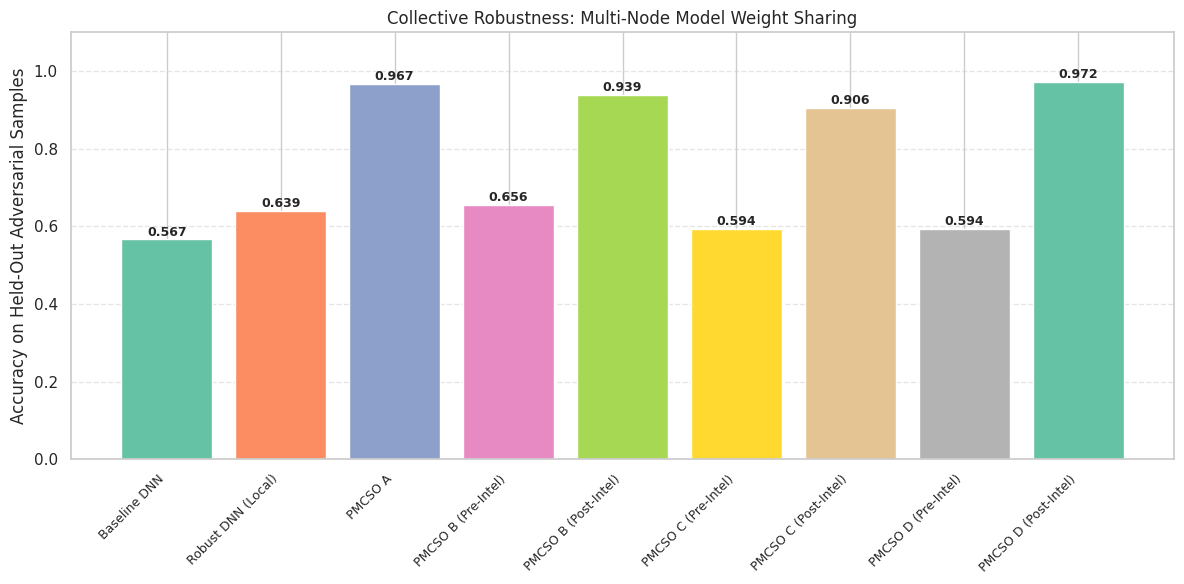

Visualization charts saved to charts/

EXPERIMENT COMPLETE
Key PoC points:
  1. Shares model weight deltas instead of adversarial sample data.
  2. Simulates configurable PMCSO nodes.
  3. Hashes shared intelligence for blockchain integrity verification.
  4. Keeps sample data off-chain and local to each node.


In [17]:
print("=" * 60)
print("Generating Final Visualizations")
print("=" * 60)

fig3, ax3 = plt.subplots(figsize=(max(12, len(gen_results) * 1.2), 6))
node_labels = list(gen_results.keys())
node_accs = [gen_results[n][0] for n in node_labels]
palette = sns.color_palette("Set2", n_colors=len(node_labels))
bars = ax3.bar(range(len(node_labels)), node_accs, color=palette)
for bar, acc in zip(bars, node_accs):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{acc:.3f}",
             ha="center", fontsize=9, fontweight="bold")
ax3.set_xticks(range(len(node_labels)))
ax3.set_xticklabels(node_labels, rotation=45, ha="right", fontsize=9)
ax3.set_ylim(0, 1.1)
ax3.set_ylabel("Accuracy on Held-Out Adversarial Samples")
ax3.set_title("Collective Robustness: Multi-Node Model Weight Sharing")
ax3.grid(axis="y", linestyle="--", alpha=0.5)
fig3.tight_layout()
fig3.savefig(Path(CONFIG.charts_dir) / "multi_node_collective_robustness.png", dpi=300, bbox_inches="tight")
plt.show()
print("Visualization charts saved to charts/")
print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)
print("Key PoC points:")
print("  1. Shares model weight deltas instead of adversarial sample data.")
print("  2. Simulates configurable PMCSO nodes.")
print("  3. Hashes shared intelligence for blockchain integrity verification.")
print("  4. Keeps sample data off-chain and local to each node.")